# Mobile game's hit potential (DNA method)

In [1]:
import pandas as pd

df_path = "../data/"
df = pd.read_parquet(df_path + "data")

In [2]:
df.sort_values(by=["game_id", "player_id", "registration_date", "event_date"], ascending=True, inplace=True)
df[["game_id", "player_id", "registration_date", "event_date"]].head()

,game_id,player_id,registration_date,event_date
391771,Game A,18338764,17742.0,17742.0
155005,Game A,18338764,17784.0,17801.0
270287,Game A,18338810,17852.0,17852.0
264778,Game A,18338870,17661.0,17663.0
362927,Game A,18338870,17768.0,17805.0


In [3]:
# Drop inputs with event_date < registration_date
condition = df["event_date"] < df["registration_date"]
num_violating_rows = condition.sum()
if num_violating_rows:
    df = df[~condition]
    print("Dropped ", num_violating_rows, " rows")
else:
    print("No rows with event_date < registration_date")

No rows with event_date < registration_date


In [4]:
# Add days_since_registration column
df["days_since_registration"] = df["event_date"] - df["registration_date"]
df[["game_id", "player_id", "registration_date", "event_date", "days_since_registration"]].head()

,game_id,player_id,registration_date,event_date,days_since_registration
391771,Game A,18338764,17742.0,17742.0,0.0
155005,Game A,18338764,17784.0,17801.0,17.0
270287,Game A,18338810,17852.0,17852.0,0.0
264778,Game A,18338870,17661.0,17663.0,2.0
362927,Game A,18338870,17768.0,17805.0,37.0


In [5]:
# Save the cleaned df as parquet (for later usage)
save_path = "../data/cleaned/cleaned_data"
df.to_parquet(save_path, index=False, engine="pyarrow")

In [6]:
# Players who play 0-10 minutes on their registration_date (day0)
minutes = list(range(0, 11))
day0_10mins_players = df.loc[(df["days_since_registration"] == 0.0) & (df["cumulative_time_spent"].isin(minutes))]
day0_10mins_players[["game_id", "player_id", "registration_date", "event_date", "days_since_registration","cumulative_time_spent"]].head()

,game_id,player_id,registration_date,event_date,days_since_registration,cumulative_time_spent
391771,Game A,18338764,17742.0,17742.0,0.0,3.0
314124,Game A,18339119,17754.0,17754.0,0.0,8.0
230806,Game A,18339319,17797.0,17797.0,0.0,8.0
121333,Game A,18339779,17670.0,17670.0,0.0,4.0
331964,Game A,18339779,17732.0,17732.0,0.0,4.0


In [7]:
# The number of players for each game_id and minutes spent (0-10) on day0
day0_10mins_player_count = day0_10mins_players.groupby(by=["game_id", "cumulative_time_spent"])["player_id"].nunique().reset_index(name='day0_player_count').rename(columns={'cumulative_time_spent':'day0_minutes'})
day0_10mins_player_count.head()

,game_id,day0_minutes,day0_player_count
0,Game A,0.0,14230
1,Game A,1.0,2979
2,Game A,2.0,4656
3,Game A,3.0,6341
4,Game A,4.0,4310


In [8]:
# Players who play the day after their registration_date (day1)
day1_players = df.loc[(df["days_since_registration"] == 1)]
day1_players[["game_id", "player_id", "registration_date", "event_date", "days_since_registration"]].head()

,game_id,player_id,registration_date,event_date,days_since_registration
267534,Game A,18339319,17678.0,17679.0,1.0
215924,Game A,18339779,17679.0,17680.0,1.0
17772,Game A,18339779,17762.0,17763.0,1.0
413303,Game A,18339779,17888.0,17889.0,1.0
130998,Game A,18340272,17616.0,17617.0,1.0


In [9]:
# Players who play 0-10 minutes on day0, and come back on day1 
day1_retained_players = day0_10mins_players.merge(day1_players, how="inner" , on=["game_id", "player_id", "registration_date"])
day1_retained_players = day1_retained_players[['game_id', 'player_id', 'time_spent_x']]
day1_retained_players = day1_retained_players.rename(columns={'time_spent_x' : 'day0_minutes'})
day1_retained_players.head()

,game_id,player_id,day0_minutes
0,Game A,18359555,0
1,Game A,18364335,0
2,Game A,18364335,0
3,Game A,18380208,3
4,Game A,18458326,4


In [10]:
# The number of players retained on day1 for each game_id and minutes spent (0-10)
day1_retained_player_count = day1_retained_players.groupby(by=["game_id", 'day0_minutes'])['player_id'].nunique().reset_index(name='day1_player_count')
day1_retained_player_count.head()

,game_id,day0_minutes,day1_player_count
0,Game A,0,41
1,Game A,1,3
2,Game A,2,9
3,Game A,3,8
4,Game A,4,8


In [11]:
# Day1 retention rate of minutes played on day0 for minutes 0-10
dna_retention = pd.merge(day0_10mins_player_count, day1_retained_player_count, on=["game_id","day0_minutes"])
dna_retention["minute_retention_rate"] = round(dna_retention["day1_player_count"] / dna_retention["day0_player_count"] * 100, 2)
dna_retention.head()

,game_id,day0_minutes,day0_player_count,day1_player_count,minute_retention_rate
0,Game A,0.0,14230,41,0.29
1,Game A,1.0,2979,3,0.10
2,Game A,2.0,4656,9,0.19
3,Game A,3.0,6341,8,0.13
4,Game A,4.0,4310,8,0.19


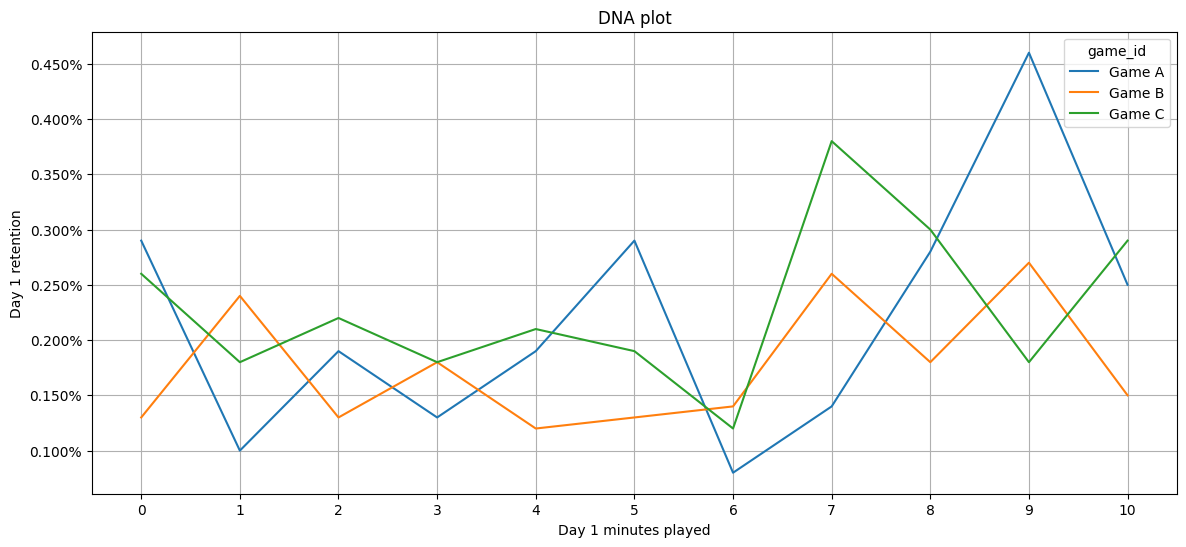

In [12]:
# DNA plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=dna_retention,
    x="day0_minutes",
    y="minute_retention_rate",
    hue="game_id")
ax.set(
    xlabel="Day 1 minutes played",
    ylabel="Day 1 retention", 
    title="DNA plot", 
    xticks=minutes)
ax.grid(True)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.show()


Observation:
- Based on the plot, game B has the weakest overall DNA. Consequently, it has the lowest potential among 3 games. 
> Companies should consider move their resources from developing game B to other games.

*NB: The data is mocked so it does not reflect reality. The DNA plots usually have less 'wormholes', and are generally flatter or trending upward*